100%|██████████| 170M/170M [00:23<00:00, 7.18MB/s]


fedavg round 1: 30.36%
fedavg round 2: 33.00%
fedavg round 3: 34.78%
fedavg round 4: 36.48%
fedavg round 5: 36.55%
fedadam round 1: 16.17%
fedadam round 2: 18.12%
fedadam round 3: 17.79%
fedadam round 4: 23.17%
fedadam round 5: 31.98%


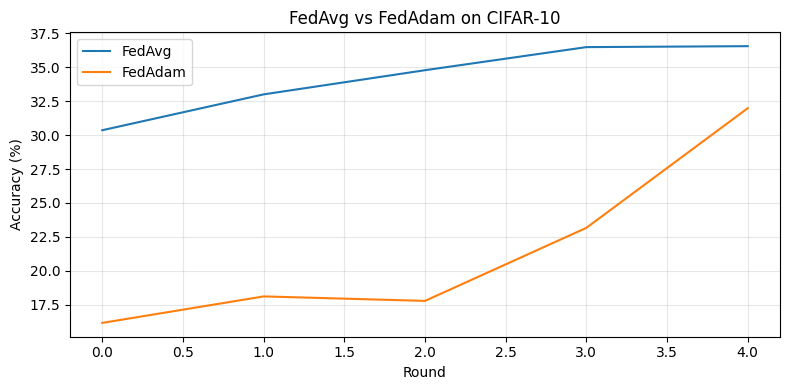

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1. DATASET (CIFAR-10)
# -------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

# simple non-IID split
def split_data(dataset, num_clients=5):
    data_per_client = len(dataset) // num_clients
    return [
        torch.utils.data.Subset(dataset, range(i * data_per_client, (i + 1) * data_per_client))
        for i in range(num_clients)
    ]

clients = split_data(trainset)

testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

# -------------------------
# 2. MODEL
# -------------------------
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*32*3, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.model(x)

# -------------------------
# 3. TRAIN LOCAL MODEL
# -------------------------
def train_local(model, loader, epochs=1):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    model.train()
    for _ in range(epochs):
        for x, y in loader:
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
    return model.state_dict()

# -------------------------
# 4. EVALUATION
# -------------------------
def evaluate(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in testloader:
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return 100 * correct / total

# -------------------------
# 5. FEDAVG AGGREGATION
# -------------------------
def fedavg(models):
    avg = {}
    for k in models[0].keys():
        avg[k] = sum(m[k] for m in models) / len(models)
    return avg

# -------------------------
# 6. FEDADAM SERVER (advanced FL method)
# -------------------------
class FedAdamServer:
    def __init__(self, model):
        self.global_model = model
        self.m = {k: torch.zeros_like(v) for k, v in model.state_dict().items()}
        self.v = {k: torch.zeros_like(v) for k, v in model.state_dict().items()}
        self.beta1 = 0.9
        self.beta2 = 0.99
        self.lr = 0.01
        self.eps = 1e-6
        self.t = 0

    def step(self, client_models):
        self.t += 1
        global_state = self.global_model.state_dict()

        delta = {
            k: sum(m[k] for m in client_models) / len(client_models) - global_state[k]
            for k in global_state
        }

        new_state = {}

        for k in global_state:
            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * delta[k]
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * (delta[k] ** 2)

            m_hat = self.m[k] / (1 - self.beta1 ** self.t)
            v_hat = self.v[k] / (1 - self.beta2 ** self.t)

            new_state[k] = global_state[k] + self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)

        self.global_model.load_state_dict(new_state)

# -------------------------
# 7. TRAINING LOOP
# -------------------------
def run_fl(algorithm="fedavg", rounds=5):
    global_model = Net()

    acc_history = []

    if algorithm == "fedadam":
        server = FedAdamServer(global_model)

    for r in range(rounds):
        client_models = []

        for client_data in clients:
            loader = torch.utils.data.DataLoader(client_data, batch_size=32, shuffle=True)
            local_model = Net()
            local_model.load_state_dict(global_model.state_dict())

            state = train_local(local_model, loader, epochs=1)
            client_models.append(state)

        # aggregation
        if algorithm == "fedavg":
            new_state = fedavg(client_models)
            global_model.load_state_dict(new_state)

        else:
            server.step(client_models)
            global_model = server.global_model

        acc = evaluate(global_model)
        acc_history.append(acc)

        print(f"{algorithm} round {r+1}: {acc:.2f}%")

    return acc_history

# -------------------------
# 8. RUN EXPERIMENT
# -------------------------
fedavg_acc = run_fl("fedavg", rounds=5)
fedadam_acc = run_fl("fedadam", rounds=5)

# -------------------------
# 9. PLOT RESULTS
# -------------------------
plt.figure(figsize=(8,4))
plt.plot(fedavg_acc, label="FedAvg")
plt.plot(fedadam_acc, label="FedAdam")
plt.xlabel("Round")
plt.ylabel("Accuracy (%)")
plt.title("FedAvg vs FedAdam on CIFAR-10")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

100%|██████████| 9.91M/9.91M [00:00<00:00, 33.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.39MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.84MB/s]


lr=0.01, epochs=1, round 1: 78.83%
lr=0.01, epochs=1, round 2: 84.68%
lr=0.01, epochs=1, round 3: 87.33%
lr=0.01, epochs=1, round 4: 88.73%
lr=0.01, epochs=1, round 5: 89.35%
lr=0.01, epochs=1, round 1: 79.07%
lr=0.01, epochs=1, round 2: 85.06%
lr=0.01, epochs=1, round 3: 87.53%
lr=0.01, epochs=1, round 4: 88.62%
lr=0.01, epochs=1, round 5: 89.41%
lr=0.05, epochs=1, round 1: 89.38%
lr=0.05, epochs=1, round 2: 91.02%
lr=0.05, epochs=1, round 3: 91.90%
lr=0.05, epochs=1, round 4: 92.35%
lr=0.05, epochs=1, round 5: 93.13%
lr=0.01, epochs=3, round 1: 87.47%
lr=0.01, epochs=3, round 2: 89.85%
lr=0.01, epochs=3, round 3: 90.70%
lr=0.01, epochs=3, round 4: 91.33%
lr=0.01, epochs=3, round 5: 91.98%
lr=0.05, epochs=3, round 1: 91.71%
lr=0.05, epochs=3, round 2: 93.23%
lr=0.05, epochs=3, round 3: 94.35%
lr=0.05, epochs=3, round 4: 95.15%
lr=0.05, epochs=3, round 5: 95.63%


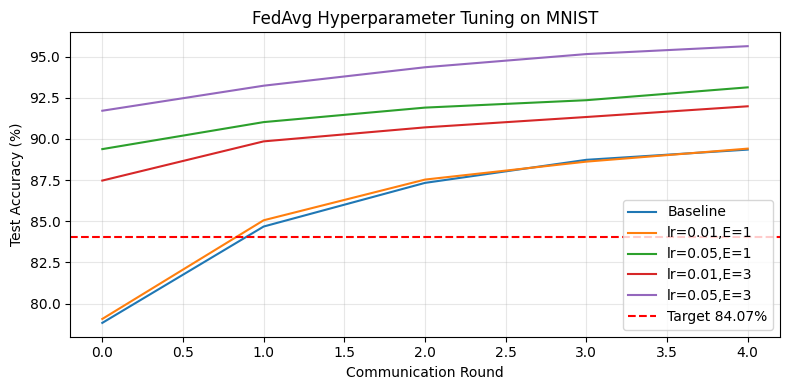

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# 1. MNIST DATASET
# -------------------------
transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

testset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

def split_clients(dataset, num_clients=5):
    size = len(dataset) // num_clients
    return [
        torch.utils.data.Subset(dataset, range(i * size, (i + 1) * size))
        for i in range(num_clients)
    ]

clients = split_clients(trainset)

testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

# -------------------------
# 2. MODEL
# -------------------------
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

# -------------------------
# 3. TRAIN LOCAL MODEL
# -------------------------
def train_local(model, loader, lr, epochs):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    model.train()
    for _ in range(epochs):
        for x, y in loader:
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

    return model.state_dict()

# -------------------------
# 4. EVALUATION
# -------------------------
def evaluate(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in testloader:
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return 100 * correct / total

# -------------------------
# 5. FEDAVG
# -------------------------
def fedavg(states):
    avg = {}
    for k in states[0].keys():
        avg[k] = sum(s[k] for s in states) / len(states)
    return avg

# -------------------------
# 6. FL TRAINING LOOP (TUNABLE)
# -------------------------
def run_fedavg(lr=0.01, local_epochs=1, rounds=5):
    global_model = Net()
    acc_history = []

    for r in range(rounds):
        client_states = []

        for client_data in clients:
            loader = torch.utils.data.DataLoader(client_data, batch_size=32, shuffle=True)

            local_model = Net()
            local_model.load_state_dict(global_model.state_dict())

            state = train_local(local_model, loader, lr=lr, epochs=local_epochs)
            client_states.append(state)

        new_state = fedavg(client_states)
        global_model.load_state_dict(new_state)

        acc = evaluate(global_model)
        acc_history.append(acc)

        print(f"lr={lr}, epochs={local_epochs}, round {r+1}: {acc:.2f}%")

    return acc_history

# -------------------------
# 7. BASELINE RUN
# -------------------------
baseline = run_fedavg(lr=0.01, local_epochs=1, rounds=5)

# -------------------------
# 8. HYPERPARAMETER SEARCH
# -------------------------
configs = [
    {"lr": 0.01, "local_epochs": 1},
    {"lr": 0.05, "local_epochs": 1},
    {"lr": 0.01, "local_epochs": 3},
    {"lr": 0.05, "local_epochs": 3},
]

results = {}

for cfg in configs:
    key = f"lr={cfg['lr']},E={cfg['local_epochs']}"
    results[key] = run_fedavg(cfg["lr"], cfg["local_epochs"], rounds=5)

# -------------------------
# 9. PLOT RESULTS
# -------------------------
plt.figure(figsize=(8,4))

plt.plot(baseline, label="Baseline")

for k, v in results.items():
    plt.plot(v, label=k)

plt.axhline(84.07, linestyle="--", color="red", label="Target 84.07%")

plt.xlabel("Communication Round")
plt.ylabel("Test Accuracy (%)")
plt.title("FedAvg Hyperparameter Tuning on MNIST")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


=== IID FedAvg ===
Round 1: 79.83%
Round 2: 85.31%
Round 3: 87.36%
Round 4: 88.67%
Round 5: 89.41%

=== Non-IID FedAvg ===
Round 1: 39.63%
Round 2: 45.18%
Round 3: 47.30%
Round 4: 52.46%
Round 5: 57.15%


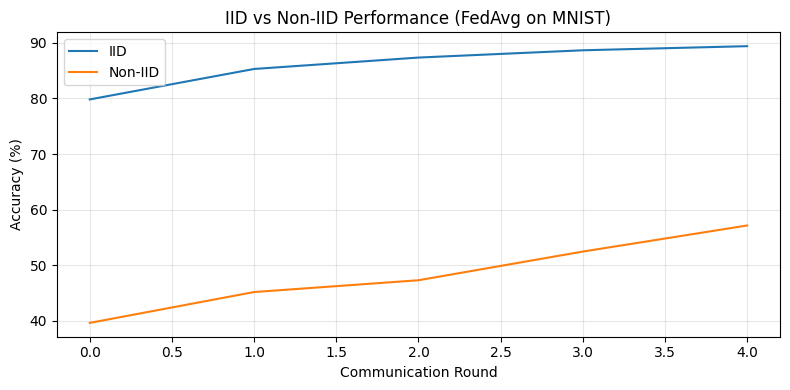

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1. DATA
# -------------------------
transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

testset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

# -------------------------
# 2. MODEL
# -------------------------
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

# -------------------------
# 3. IID / NON-IID SPLITS
# -------------------------
def iid_split(dataset, num_clients=5):
    size = len(dataset) // num_clients
    return [
        torch.utils.data.Subset(dataset, range(i * size, (i + 1) * size))
        for i in range(num_clients)
    ]

def non_iid_split(dataset, num_clients=5, num_shards=10):
    labels = np.array(dataset.targets)
    idxs = np.arange(len(dataset))

    idxs_labels = np.vstack((idxs, labels))
    idxs_labels = idxs_labels[:, idxs_labels[1, :].argsort()]
    idxs = idxs_labels[0, :]

    shards = np.array_split(idxs, num_shards)
    client_data = [[] for _ in range(num_clients)]

    for i, shard in enumerate(shards):
        client_data[i % num_clients].extend(shard)

    return [
        torch.utils.data.Subset(dataset, client_data[i])
        for i in range(num_clients)
    ]

# -------------------------
# 4. TRAIN LOCAL MODEL
# -------------------------
def train_local(model, loader, lr=0.01):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    model.train()
    for x, y in loader:
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

    return model.state_dict()

# -------------------------
# 5. FEDAVG
# -------------------------
def fedavg(states):
    avg = {}
    for k in states[0]:
        avg[k] = sum(s[k] for s in states) / len(states)
    return avg

# -------------------------
# 6. EVALUATION
# -------------------------
def evaluate(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in testloader:
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return 100 * correct / total

# -------------------------
# 7. FEDERATED TRAINING LOOP
# -------------------------
def run_fl(clients, rounds=5):
    global_model = Net()
    history = []

    for r in range(rounds):
        client_states = []

        for data in clients:
            loader = torch.utils.data.DataLoader(data, batch_size=32, shuffle=True)

            local_model = Net()
            local_model.load_state_dict(global_model.state_dict())

            state = train_local(local_model, loader)
            client_states.append(state)

        new_state = fedavg(client_states)
        global_model.load_state_dict(new_state)

        acc = evaluate(global_model)
        history.append(acc)

        print(f"Round {r+1}: {acc:.2f}%")

    return history

# -------------------------
# 8. RUN IID vs NON-IID
# -------------------------
iid_clients = iid_split(trainset, num_clients=5)
non_iid_clients = non_iid_split(trainset, num_clients=5)

print("\n=== IID FedAvg ===")
iid_results = run_fl(iid_clients)

print("\n=== Non-IID FedAvg ===")
non_iid_results = run_fl(non_iid_clients)

# -------------------------
# 9. PLOT
# -------------------------
plt.figure(figsize=(8,4))

plt.plot(iid_results, label="IID")
plt.plot(non_iid_results, label="Non-IID")

plt.xlabel("Communication Round")
plt.ylabel("Accuracy (%)")
plt.title("IID vs Non-IID Performance (FedAvg on MNIST)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()